In [27]:
from pathlib import Path

import sys
# Add src to path for importing local modules
sys.path.insert(0, str(Path("../src").resolve()))

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

from trompy import save_figure_atomic

from src.outlier_filter import robust_tail_filter_log_area
from src.add_extra_columns import add_extra_columns

mpl.rcParams["figure.dpi"] = 150
mpl.rcParams["font.size"] = 8
mpl.rcParams["font.family"] = "Arial"
mpl.rcParams['savefig.transparent'] = True

SAVEFIGS = True

In [28]:
DATAFOLDER = Path("./data")
METAFILE = Path("./data/fenestrations_metafile.xlsx")
FIGSFOLDER = Path("./figs/paper1/panels")
IMAGESFOLDER = Path("C:/Users/jmc010/Data/fenestrations/images")
SEGFOLDER = Path("C:/Users/jmc010/Data/fenestrations/flatten_npy")

# Ensure output folder exists for direct saves.
FIGSFOLDER.mkdir(parents=True, exist_ok=True)

# save_figure_atomic stages files under _tmp/<relative output path>;
# ensure that staging path exists when using relative figure folders.
(Path.cwd() / "_tmp" / FIGSFOLDER).mkdir(parents=True, exist_ok=True)

data = pd.read_pickle(DATAFOLDER / "roi_data.pickle")

# Extract the DataFrames
rois_df = data['rois']
summary_df = data['summary']

# load metafile
metadata = pd.read_excel(METAFILE)

print("ROI Data Statistics")
print("=" * 50)
print(f"\nROIs DataFrame:")
print(f"  Rows: {len(rois_df)}")
print(f"  Columns: {len(rois_df.columns)}")
print(f"  Column names: {list(rois_df.columns)}")
print(f"\n  Memory usage: {rois_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print(f"\n\nSummary DataFrame:")
print(f"  Rows: {len(summary_df)}")
print(f"  Columns: {len(summary_df.columns)}")
print(f"  Column names: {list(summary_df.columns)}")
print(f"\n  Memory usage: {summary_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\n" + "=" * 50)
print("\nFirst few rows of ROIs DataFrame:")
print(rois_df.head())

print("\n" + "=" * 50)
print("\nFirst few rows of Summary DataFrame:")
print(summary_df.head())

print("\n" + "=" * 50)
print("\nData types:")
print("\nROIs DataFrame:")
print(rois_df.dtypes)
print("\nSummary DataFrame:")
print(summary_df.dtypes)

ROI Data Statistics

ROIs DataFrame:
  Rows: 234865
  Columns: 33
  Column names: ['id', 'stub', 'roi_id', 'centroid_x', 'centroid_y', 'pixel_count', 'pixel_size', 'area', 'cluster_neighbor_count', 'cluster_neighbor_ids', 'cluster_max_internal_angle_deg', 'cluster_max_angular_gap_deg', 'cluster_is_convex', 'cluster_center_inside_polygon', 'cluster_is_valid', 'cluster_neighbor_distance', 'profile_major', 'profile_minor', 'profile_diag45', 'profile_diag135', 'four_axis_mean', 'major_axis_angle', 'major_axis_extent', 'minor_axis_extent', 'major_axis_length_px', 'minor_axis_length_px', 'step_major', 'step_minor', 'step_diag45', 'step_diag135', 'diameter_area', 'experiment', 'condition']

  Memory usage: 262.44 MB


Summary DataFrame:
  Rows: 548
  Columns: 20
  Column names: ['id', 'stub', 'mean_neighbor_count', 'mean_cluster_neighbor_distance_px', 'mean_cluster_neighbor_distance_nm', 'mean_roi_area_nm2', 'mean_pixel_size_nm_per_px', 'mean_diameter_area_nm', 'mean_diameter_major_nm', 'mean

In [29]:
def get_filtered_control_data(rois_df, summary_df):
    
    rois_df, _ = robust_tail_filter_log_area(rois_df)
    rois_df = rois_df.query("condition == 'control'").reset_index(drop=True)
    summary_df = summary_df.query("condition == 'control'").reset_index(drop=True)
    
    return rois_df, summary_df

rois_df, summary_df = get_filtered_control_data(rois_df, summary_df)

# Add extra derived columns once so downstream plotting cells can rely on them.
rois_df, summary_df = add_extra_columns(
    rois_df,
    summary_df,
    union_dir=Path("./union_masks"),
    images_path=None,
    add_union_area=True,
)

In [30]:
summary_df.columns

Index(['id', 'stub', 'mean_neighbor_count',
       'mean_cluster_neighbor_distance_px',
       'mean_cluster_neighbor_distance_nm', 'mean_roi_area_nm2',
       'mean_pixel_size_nm_per_px', 'mean_diameter_area_nm',
       'mean_diameter_major_nm', 'mean_diameter_minor_nm',
       'mean_diameter_four_axis_nm', 'mean_profile_major_smpls',
       'mean_profile_minor_smpls', 'mean_four_axis_smpls', 'porosity_square',
       'porosity_hex', 'porosity_blend', 'blend_weight', 'experiment',
       'condition', 'mean_diameter_p2p_major_nm', 'mean_diameter_p2p_minor_nm',
       'mean_diameter_p2p_nm', 'mean_diameter_fwhm_major_nm',
       'mean_diameter_fwhm_minor_nm', 'mean_diameter_fwhm_nm',
       'mean_diameter_deriv_major_nm', 'mean_diameter_deriv_minor_nm',
       'mean_diameter_deriv_nm', 'cell_area_square_nm2', 'cell_area_hex_nm2',
       'cell_area_blend_nm2', 'density_lattice_square', 'density_lattice_hex',
       'density_lattice_blend', 'union_mask_area_um2', 'roi_count',
       'dens

In [31]:
def init_diameter_panel():
    f, ax = plt.subplots(figsize=(1.5, 1.5),
                         gridspec_kw={"left": 0.25, "right": 0.95, "top": 0.85, "bottom": 0.37})
    
    return f, ax

lattice_color = "#1f77b4"
union_color = "#ff7f0e"

SAVEFIGS = True

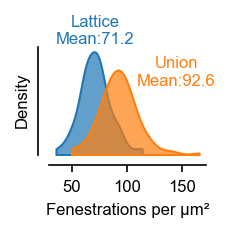

In [54]:
f, ax = init_diameter_panel()

sns.kdeplot(
    data=summary_df.density_lattice_blend,
    fill=True, ax=ax, color=lattice_color, alpha=0.7,
            cut=0)

sns.kdeplot(
    data=summary_df.density_union,
    fill=True, ax=ax, color=union_color, alpha=0.7,
            cut=0)

# ax.set_xlim(xlims)
ax.set_xlabel("Fenestrations per µm²")

ax.set_yticks([])

ax.text(71, 0.032, f"Lattice\nMean:{summary_df.density_lattice_blend.mean():.1f}", ha="center", color=lattice_color)
ax.text(145, 0.020, f"Union\nMean:{summary_df.density_union.mean():.1f}", ha="center", color=union_color)

sns.despine(offset=5)

if SAVEFIGS:
    save_figure_atomic(f, FIGSFOLDER / "density_panel")

C:\Users\jmc010\AppData\Local\Temp\ipykernel_24776\156554780.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(["circular",


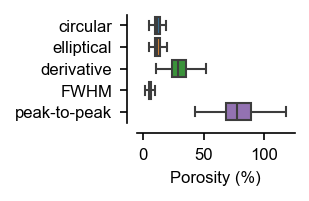

In [57]:
f, ax = plt.subplots(figsize=(2.1, 1.5),
                         gridspec_kw={"left": 0.45, "right": 0.95, "top": 0.85, "bottom": 0.37})
    

sns.boxplot(
    data=[summary_df.porosity_blend_area,
          summary_df.porosity_blend,
          summary_df.porosity_blend_profile_deriv,
          summary_df.porosity_blend_profile_fwhm,
          summary_df.porosity_blend_profile_p2p
          ],
    fliersize=0,
    ax=ax,
    orient="h",
)


ax.set_yticklabels(["circular",
                    "elliptical",
                    "derivative",
                    "FWHM",
                    "peak-to-peak"])

ax.set_xlabel("Porosity (%)")
ax.set_xticks([0, 0.5, 1], labels=["0", "50", "100"])
ax.set_xlim(-0.05, 1.25)

sns.despine(offset=5)

if SAVEFIGS:
    save_figure_atomic(f, FIGSFOLDER / "porosity_panel")

In [33]:
summary_df.columns

Index(['id', 'stub', 'mean_neighbor_count',
       'mean_cluster_neighbor_distance_px',
       'mean_cluster_neighbor_distance_nm', 'mean_roi_area_nm2',
       'mean_pixel_size_nm_per_px', 'mean_diameter_area_nm',
       'mean_diameter_major_nm', 'mean_diameter_minor_nm',
       'mean_diameter_four_axis_nm', 'mean_profile_major_smpls',
       'mean_profile_minor_smpls', 'mean_four_axis_smpls', 'porosity_square',
       'porosity_hex', 'porosity_blend', 'blend_weight', 'experiment',
       'condition', 'mean_diameter_p2p_major_nm', 'mean_diameter_p2p_minor_nm',
       'mean_diameter_p2p_nm', 'mean_diameter_fwhm_major_nm',
       'mean_diameter_fwhm_minor_nm', 'mean_diameter_fwhm_nm',
       'mean_diameter_deriv_major_nm', 'mean_diameter_deriv_minor_nm',
       'mean_diameter_deriv_nm', 'cell_area_square_nm2', 'cell_area_hex_nm2',
       'cell_area_blend_nm2', 'density_lattice_square', 'density_lattice_hex',
       'density_lattice_blend', 'union_mask_area_um2', 'roi_count',
       'dens

In [23]:
rois_df.columns

Index(['id', 'stub', 'roi_id', 'centroid_x', 'centroid_y', 'pixel_count',
       'pixel_size', 'area', 'cluster_neighbor_count', 'cluster_neighbor_ids',
       'cluster_max_internal_angle_deg', 'cluster_max_angular_gap_deg',
       'cluster_is_convex', 'cluster_center_inside_polygon',
       'cluster_is_valid', 'cluster_neighbor_distance', 'profile_major',
       'profile_minor', 'profile_diag45', 'profile_diag135', 'four_axis_mean',
       'major_axis_angle', 'major_axis_extent', 'minor_axis_extent',
       'major_axis_length_px', 'minor_axis_length_px', 'step_major',
       'step_minor', 'step_diag45', 'step_diag135', 'diameter_area',
       'experiment', 'condition', 'robust_z_log_area'],
      dtype='object')